In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("IPL.csv")
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [3]:
# Basic information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

In [4]:
# check size of rows and columns
df.shape

(74, 20)

In [5]:
# how many columns have null values in total
df.isna().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

<Axes: ylabel='match_winner'>

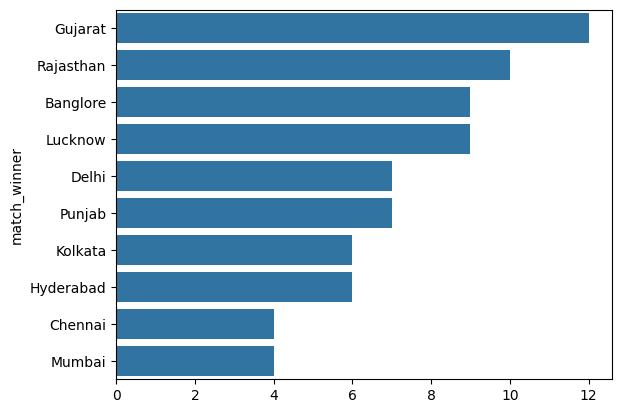

In [6]:
# which team won the most matches
match_wins=df["match_winner"].value_counts()
sns.barplot(y=match_wins.index,x=match_wins.values)

<Axes: xlabel='count', ylabel='toss_decision'>

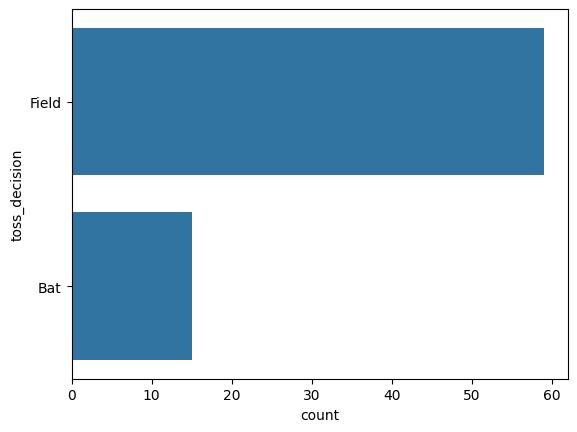

In [7]:
# Toss decision trends
sns.countplot(df["toss_decision"])

In [8]:
# toss winner vs match winner
df[df["toss_winner"]==df["match_winner"]]['match_id'].count()

np.int64(36)

<Axes: xlabel='won_by', ylabel='count'>

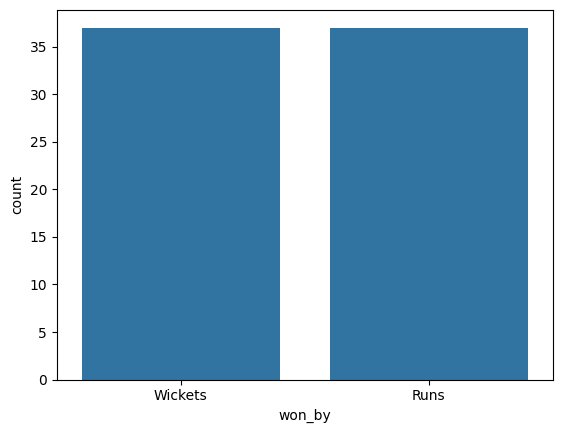

In [9]:
# how do teams win(run vs wickets)
sns.countplot(x=df["won_by"])

<Axes: ylabel='player_of_the_match'>

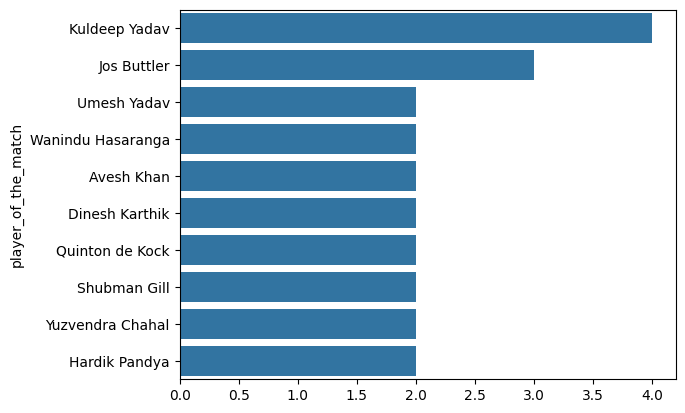

In [10]:
# Most player of the match awards
motm=df["player_of_the_match"].value_counts().head(10)
sns.barplot(x=motm.values,y=motm.index)

<Axes: xlabel='top_scorer', ylabel='highscore'>

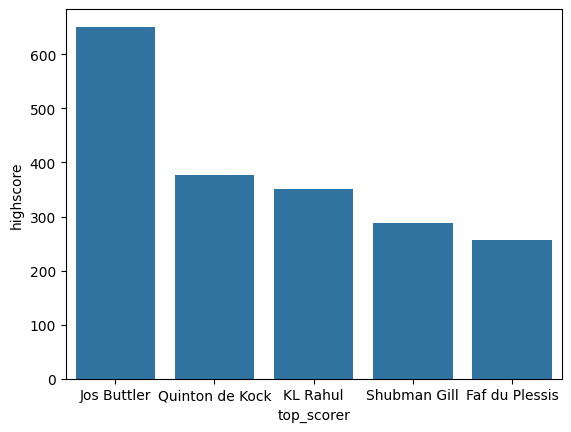

In [11]:
# Top scorers
top=df.groupby("top_scorer")["highscore"].sum().sort_values(ascending=False).head()
sns.barplot(top)

<Axes: xlabel='best_bowling', ylabel='highest_wickets'>

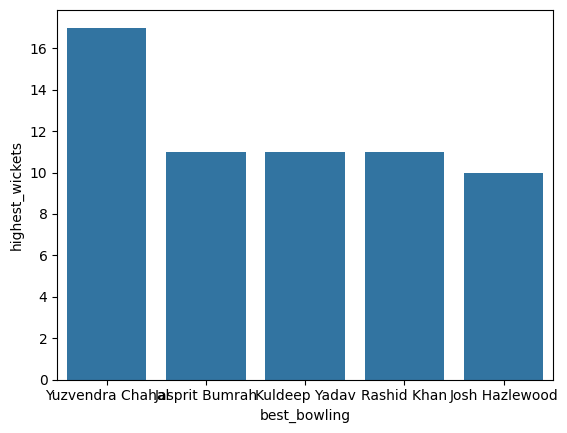

In [12]:
# best bowling figures
df["highest_wickets"]=df["best_bowling_figure"].apply(lambda x: int(x.split("--")[0]))
bestbo=df.groupby("best_bowling")["highest_wickets"].sum().sort_values(ascending=False).head()
sns.barplot(bestbo)

In [13]:
# Most matches played by venue
df.groupby("venue")["match_id"].count().sort_values(ascending=False)

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: match_id, dtype: int64

In [14]:
# who won the highest margin by runs
df[df["won_by"]=="Runs"].sort_values(by="margin", ascending=False)[["match_winner","margin"]].head(1)

,match_winner,margin
54,Chennai,91


In [15]:
# which player had the highest individual score
df[df["highscore"]==df["highscore"].max()]

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
65,66,"May 18,2022","Dr DY Patil Sports Academy, Mumbai",Kolkata,Lucknow,Group,Lucknow,Bat,210,0,...,8,Lucknow,Runs,2,Quinton de Kock,Quinton de Kock,140,Mohsin Khan,3--20,3


In [19]:
# which bowler had the best bowling figure
df[df["highest_wickets"]==df["highest_wickets"].max()][["best_bowling","best_bowling_figure"]]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
